**Representación del conocimiento y herramientas de visualización**

En esta sección vamos a trabajar con distintas formas de representación del conocimiento.
Para que sea más claro y didáctico, vamos a graficar algunos ejemplos.

Para eso usaremos dos librerías de Python:

networkx: permite crear y manejar redes y grafos, lo que nos servirá para representar redes semánticas y relaciones entre conceptos en construcción.

Ejemplo: representar que una casa está formada por muros, que a su vez están hechos de ladrillos unidos con cemento.

matplotlib: nos ayudará a visualizar gráficamente esas redes o estructuras, generando diagramas que ilustren cómo se organiza el conocimiento.

Ejemplo: un diagrama que muestre la jerarquía de materiales → muro → ladrillo.

Estas herramientas no forman parte del sistema experto en sí, pero nos van a permitir entender mejor cómo se organiza el conocimiento que luego un sistema experto podría usar para razonar y tomar decisiones

In [ ]:
pip install networkx matplotlib


**Representación del conocimiento con Conjuntos**

Una de las formas más simples de representar conocimiento en un sistema experto es mediante conjuntos.

¿Qué es un conjunto en este contexto?
Un conjunto es simplemente una colección de elementos relacionados que comparten una característica en común. En la construcción podemos pensar en conjuntos de:

Materiales básicos (cemento, arena, cal).

Herramientas de obra (martillo, taladro, sierra).

Tipos de estructuras (muros, columnas, losas).

 ¿Por qué sirve?
El uso de conjuntos nos permite:

Organizar la información de manera clara.

Hacer consultas rápidas: verificar si un elemento pertenece o no a un conjunto.

Construir las primeras reglas simples de un sistema experto.

 Ejemplo aplicado en construcción
En el código definimos dos conjuntos:

materiales_basicos = {"Cemento", "Arena", "Cal"}

herramientas = {"Martillo", "Taladro", "Sierra"}

Luego creamos funciones para consultar:

Si un ítem es un material básico.

Si un ítem es una herramienta.

Si un ítem es útil para la construcción (pertenece a alguno de los conjuntos).

Aplicación real:
Imaginemos un sistema experto que ayuda a un maestro mayor de obras a verificar qué recursos tiene disponibles en una obra.

Si el usuario ingresa “Cemento”, el sistema confirma que es un material básico necesario para construcción.

Si ingresa “Ladrillo”, el sistema responde False, porque en este ejemplo no lo hemos cargado en el conjunto (aunque podría agregarse).

Si ingresa “Martillo”, el sistema lo reconoce como herramienta útil.

Si ingresa “Vidrio”, responde que no está en los conjuntos. Esto refleja una limitación: el conocimiento cargado es parcial y hay que alimentar la base de datos con más elementos (ejemplo: vidrios para ventanas, que podrían formar parte de otro conjunto).

De esta forma, el sistema experto puede empezar a filtrar y clasificar recursos de una obra, asegurando que se identifiquen los materiales y herramientas necesarios antes de comenzar una tarea.

In [ ]:
# Conjuntos que representan hechos: materiales básicos y herramientas en construcción
materiales_basicos = {"Cemento", "Arena", "Cal"}  # Conjunto de materiales básicos
herramientas = {"Martillo", "Taladro", "Sierra"}  # Conjunto de herramientas

# Función que verifica si un ítem es un material básico
def es_material_basico(item):
    return item in materiales_basicos  # Devuelve True si el item está en materiales_basicos

# Función que verifica si un ítem es una herramienta
def es_herramienta(item):
    return item in herramientas  # Devuelve True si el item está en herramientas

# Función que dice si un ítem es útil para construcción (material o herramienta)
def es_util_para_construccion(item):
    # Devuelve True si el ítem es un material básico o una herramienta
    return es_material_basico(item) or es_herramienta(item)

# Ahora sí, imprimimos para ver resultados
print(es_util_para_construccion("Cemento"))  # Debe mostrar True
print(es_util_para_construccion("Ladrillo"))  # Debe mostrar False, porque no está en los conjuntos
print(es_util_para_construccion("Martillo"))  # Debe mostrar True
print(es_util_para_construccion("Vidrio"))  # Debe mostrar False





True
False
True
False


**Representación del conocimiento con Redes Semánticas**

Otra forma muy utilizada de representar conocimiento en inteligencia artificial es a través de las redes semánticas.

👉 ¿Qué son?
Son grafos (redes de nodos y aristas) donde:

Los nodos representan conceptos.

Las aristas (flechas) representan relaciones entre esos conceptos.

👉 ¿Por qué son útiles?

Permiten organizar jerárquicamente la información.

Muestran relaciones entre categorías y subcategorías.

Facilitan la búsqueda de conocimiento y el razonamiento.

👉 Ejemplo aplicado a la construcción
En este caso armamos una red semántica muy simple con algunos elementos:

Los nodos: "Cemento", "Arena", "Martillo", y dos categorías: "Material" y "Herramienta".

Las relaciones:

Cemento → es un → Material

Arena → es un → Material

Martillo → es una → Herramienta

Esto nos permite visualizar cómo se relacionan distintos conceptos dentro del mundo de la construcción.

👉 Aplicación real
Un sistema experto para construcción podría ampliar esta red con muchos más nodos:

Ladrillo → es un → Material.

Taladro → es una → Herramienta.

Muro → se construye con → Ladrillo + Cemento.

Losa → se construye con → Hormigón + Acero.

Con una red semántica, el sistema puede razonar recorriendo relaciones.
Ejemplo: si sabe que el Cemento es un Material y que los Materiales son necesarios para construir Muros, entonces puede inferir que el Cemento es necesario para Muros.

👉 Analogía con la vida real en obra
Es como un mapa conceptual digital que organiza todo lo que un maestro mayor de obras o un ingeniero sabe: materiales, herramientas, estructuras y cómo se conectan.

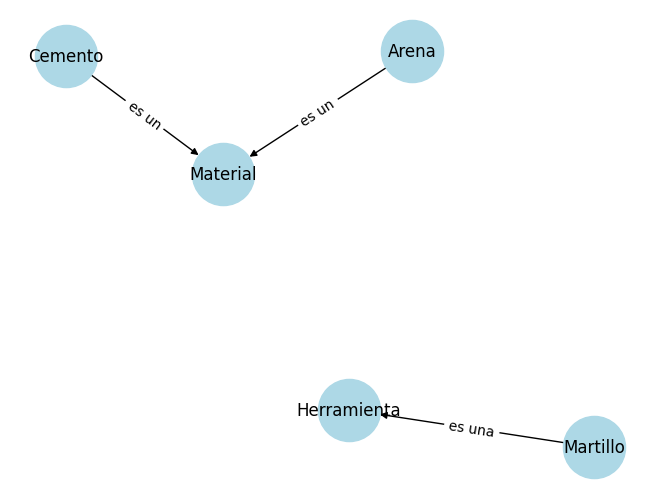

In [ ]:
# 2. Redes semánticas

# Importamos librerías para crear y visualizar grafos
import networkx as nx
import matplotlib.pyplot as plt

# Creamos un grafo dirigido (las relaciones tienen dirección)
G = nx.DiGraph()

# Agregamos nodos que representan conceptos de construcción
G.add_node("Cemento", tipo="Material")  # Nodo 'Cemento' con atributo tipo=Material
G.add_node("Arena", tipo="Material")    # Nodo 'Arena' con atributo tipo=Material
G.add_node("Martillo", tipo="Herramienta")  # Nodo 'Martillo' con atributo tipo=Herramienta
G.add_node("Herramienta", tipo="Categoría")  # Nodo categoría para 'Herramienta'
G.add_node("Material", tipo="Categoría")     # Nodo categoría para 'Material'

# Agregamos aristas que representan relaciones entre nodos
G.add_edge("Cemento", "Material", relation="es un")  # 'Cemento' es un 'Material'
G.add_edge("Arena", "Material", relation="es un")    # 'Arena' es un 'Material'
G.add_edge("Martillo", "Herramienta", relation="es una")  # 'Martillo' es una 'Herramienta'

# Posicionamos los nodos para que el grafo se vea ordenado
pos = nx.spring_layout(G)

# Dibujamos el grafo con etiquetas en los nodos y un color
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue')

# Obtenemos las etiquetas de las relaciones para mostrarlas en las aristas
edge_labels = nx.get_edge_attributes(G, 'relation')

# Dibujamos las etiquetas de las relaciones en el grafo
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Mostramos el gráfico
plt.show()


**Representación del conocimiento con Marcos o Frames**

Otra forma muy utilizada de representar conocimiento en inteligencia artificial es a través de los marcos (o frames).

👉 ¿Qué son?
Son estructuras que representan objetos o conceptos del mundo real de manera organizada.

Cada marco contiene:

Atributos: características o propiedades del objeto.

Valores: información específica de cada atributo.

Permiten describir qué es un objeto, cómo es y para qué sirve, facilitando que un sistema experto pueda razonar sobre él.

👉 ¿Por qué son útiles?

Permiten organizar la información de manera estructurada.

Facilitan el razonamiento automatizado al tener la información lista para usar.

Son flexibles y jerárquicos: un marco puede heredar atributos de otro más general.

👉 Ejemplo aplicado a herramientas

En este caso, armamos un marco simple que representa un martillo con sus atributos principales:
En este ejemplo:

"nombre" indica cómo se llama el objeto.

"tipo" clasifica el objeto dentro de una categoría más general.

"peso_kg" describe una característica física.

"uso" indica la función principal del objeto.

👉 Aplicación real

Un sistema experto podría utilizar muchos marcos para razonar y tomar decisiones:

Sabiendo que un martillo es una herramienta y que las herramientas son necesarias para ciertos trabajos, puede inferir qué herramienta usar en cada caso.

Se pueden crear marcos para clavos, tornillos, taladros, etc., y vincularlos mediante reglas o relaciones.

👉 Analogía con la vida real

Es como una ficha técnica digital que organiza todo lo que un maestro mayor de obras o ingeniero sabe sobre cada objeto:

Qué es

Cómo es

Para qué sirve

Esto permite que un sistema experto tenga conocimiento estructurado, listo para usar en la toma de decisiones automatizada.

In [ ]:
# 3. Marcos o Frames

# Creamos un diccionario que representa un objeto 'martillo' con sus atributos
martillo = {
    "nombre": "Martillo",           # Nombre del objeto
    "tipo": "Herramienta manual",   # Tipo de herramienta
    "peso_kg": 1.2,                 # Peso en kilogramos
    "uso": "Clavar clavos"          # Descripción del uso principal
}

# Imprimimos el diccionario para ver su contenido
print(martillo)

{'nombre': 'Martillo', 'tipo': 'Herramienta manual', 'peso_kg': 1.2, 'uso': 'Clavar clavos'}


Representación del conocimiento con Sistemas Basados en Reglas

Otra forma muy utilizada de representar conocimiento en inteligencia artificial es a través de sistemas basados en reglas.

Son sistemas que toman decisiones o hacen inferencias siguiendo un conjunto de reglas condicionales del tipo: si----entoces
Por qué son útiles?

Permiten codificar el conocimiento experto en forma de reglas claras.

Facilitan la toma de decisiones automatizada.

Se pueden ampliar fácilmente añadiendo nuevas reglas sin modificar el sistema completo.

**Analogía con la vida real**

Es como seguir el consejo de un experto:

Le dices qué tarea querés hacer.

Él te dice qué herramienta usar, basándose en su experiencia.

El sistema experto hace lo mismo, pero automatizado, usando reglas codificadas en su conocimiento.

Ejemplo

En este caso, tenemos un sistema que recomienda la herramienta adecuada según la tarea a realizar:


In [ ]:
# 4. Sistemas basados en reglas

# Definimos una variable que representa la tarea a realizar
tarea = "clavar clavos"

# Usamos una estructura condicional para decidir qué equipo recomendar
if tarea == "clavar clavos":      # Si la tarea es clavar clavos
    equipo_recomendado = "Martillo"  # Recomendamos un martillo
elif tarea == "perforar pared":  # Si la tarea es perforar la pared
    equipo_recomendado = "Taladro"   # Recomendamos un taladro
else:                            # Para cualquier otra tarea
    equipo_recomendado = "Equipo no definido"  # No hay recomendación específica

# Imprimimos la recomendación final
print(f"Para la tarea '{tarea}', se recomienda usar: {equipo_recomendado}")

Para la tarea 'clavar clavos', se recomienda usar: Martillo
